In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from finta import TA
import yfinance as yf

In [ ]:
stock = ['MSFT']
df = yf.download(stock, '2017-01-01', '2021-01-01')

df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df.columns]
df.columns = [c.split('_')[0].lower() for c in df.columns]
df

/tmp/ipykernel_178/3327446350.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, '2017-01-01', '2021-01-01')
[*********************100%***********************]  1 of 1 completed


,close,high,low,open,volume
Date,,,,,
2017-01-03,56.171112,56.404484,55.767196,56.359605,20694100
2017-01-04,55.919781,56.323696,55.758214,56.081347,21340000
2017-01-05,55.919781,56.242913,55.677431,55.821045,24876000
2017-01-06,56.404476,56.682730,55.686406,55.919777,19922900
2017-01-09,56.224949,56.619890,56.135191,56.332659,20382700
...,...,...,...,...,...
2020-12-24,213.250732,214.074058,211.766830,211.977449,10550600
2020-12-28,215.366501,216.390863,213.509231,214.878241,17933500
2020-12-29,214.591049,217.491833,214.045365,216.658939,17403200


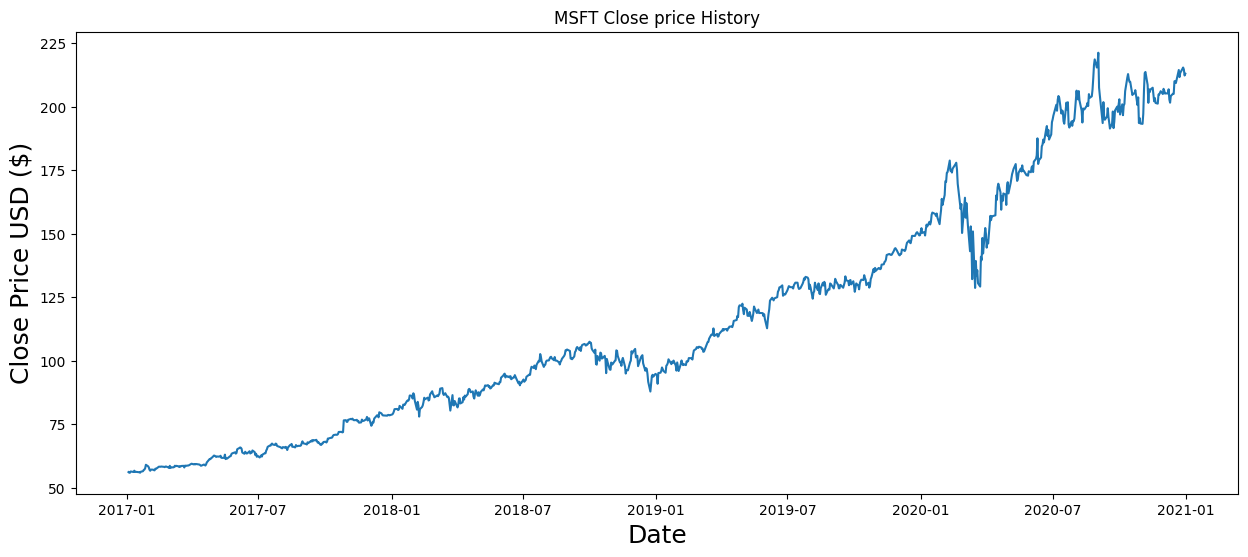

In [4]:
plt.figure(figsize=(15,6))
plt.title('MSFT Close price History')
plt.plot(df['close'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [5]:
df.describe()

,close,high,low,open,volume
count,1007.000000,1007.000000,1007.000000,1007.000000,1.007000e+03
mean,116.535026,117.656807,115.280083,116.511078,2.907935e+07
std,46.243971,46.865803,45.569627,46.220315,1.355701e+07
min,55.919781,56.242913,55.605624,55.821045,7.425600e+06
25%,79.251186,80.104592,78.457440,79.214477,2.028265e+07
50%,102.621643,103.639319,101.407857,102.538320,2.539980e+07
75%,146.029152,147.535487,143.287653,144.278979,3.329715e+07
max,221.192108,222.347489,217.086244,218.919557,1.112421e+08


In [6]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [7]:
df['SMA200'] = TA.SMA(df, 200)
df['RSI'] = TA.RSI(df)
df['ATR'] = TA.ATR(df)
df['BBWidth'] = TA.BBWIDTH(df)
df['Williams'] = TA.WILLIAMS(df)

df = df.iloc[200:, :]

In [8]:
df.tail(10)

,close,high,low,open,volume,SMA200,RSI,ATR,BBWidth,Williams
Date,,,,,,,,,,
2020-12-17,210.062729,211.470041,208.626697,210.493535,32515800,187.421508,59.818180,3.453318,0.046476,-12.478854
2020-12-18,209.268158,210.321254,206.807764,209.268158,63354900,187.700466,57.966647,3.404085,0.049241,-19.524437
2020-12-21,213.097565,214.447438,208.014014,208.272504,37181900,188.050579,63.784656,3.592137,0.056365,-9.469492
2020-12-22,214.390030,216.007962,212.389162,213.193336,22612200,188.358235,65.519369,3.617438,0.062941,-10.230042
2020-12-23,211.594528,214.026203,211.383909,213.595396,18699600,188.686537,58.942910,3.645476,0.065844,-27.905754
2020-12-24,213.250732,214.074058,211.766830,211.977449,10550600,189.092320,61.414013,3.672143,0.070323,-17.433720
2020-12-28,215.366501,216.390863,213.509231,214.878241,17933500,189.414784,64.364693,3.722064,0.077889,-6.323847
2020-12-29,214.591049,217.491833,214.045365,216.658939,17403200,189.844558,62.478886,3.690608,0.081774,-16.768148
2020-12-30,212.226334,216.007895,212.025297,215.624945,20272300,190.209551,56.994925,3.646843,0.083148,-30.437523


In [9]:
df['target'] = df.close.shift(-1)
df.dropna(inplace=True)
df.head()

/tmp/ipykernel_178/3051925840.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['target'] = df.close.shift(-1)
/tmp/ipykernel_178/3051925840.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


,close,high,low,open,volume,SMA200,RSI,ATR,BBWidth,Williams,target
Date,,,,,,,,,,,
2017-10-18,70.861435,71.080564,70.642306,70.916215,13300700,62.681459,72.604135,0.632610,0.081429,-6.250488,71.135368
2017-10-19,71.135368,71.153626,70.624058,70.824929,15092800,62.757536,74.322648,0.626742,0.084517,-0.473853,71.957100
2017-10-20,71.957100,72.103191,71.418407,71.509710,22866400,62.837723,78.649282,0.649568,0.090518,-3.041889,71.975349
2017-10-23,71.975349,72.440997,71.911437,72.121433,20627200,62.915577,78.734980,0.642394,0.090489,-9.058534,72.002769
2017-10-24,72.002769,72.313202,71.637550,72.039292,17517200,62.994467,78.872199,0.624785,0.088069,-10.958163,71.792740


In [10]:
def train_test_split(data, perc):
    data = data.values
    n = int(len(data) *(1 - perc))
    return data[:n], data[n:]

In [11]:
train, test = train_test_split(df, 0.2)
train

array([[ 7.08614349e+01,  7.10805638e+01,  7.06423061e+01, ...,
         8.14285263e-02, -6.25048823e+00,  7.11353683e+01],
       [ 7.11353683e+01,  7.11536262e+01,  7.06240582e+01, ...,
         8.45173051e-02, -4.73852692e-01,  7.19570999e+01],
       [ 7.19570999e+01,  7.21031905e+01,  7.14184065e+01, ...,
         9.05177282e-02, -3.04188912e+00,  7.19753494e+01],
       ...,
       [ 1.74402878e+02,  1.75305286e+02,  1.73433969e+02, ...,
         1.18792755e-01, -5.15181603e+00,  1.75428757e+02],
       [ 1.75428757e+02,  1.75732734e+02,  1.74174887e+02, ...,
         1.16629790e-01, -1.69405408e+00,  1.77385559e+02],
       [ 1.77385559e+02,  1.78116977e+02,  1.73690423e+02, ...,
         1.15260222e-01, -4.24940402e+00,  1.73367462e+02]])

In [13]:
X = train[:,:-1]
y = train[:,-1]
y

array([ 71.13536835,  71.95709991,  71.97534943,  72.00276947,
        71.79273987,  71.91145325,  76.52233124,  76.59538269,
        75.94710541,  75.94710541,  76.74146271,  76.82363892,
        77.12495422,  76.94233704,  77.20708466,  76.77799988,
        76.57712555,  76.63189697,  76.74146271,  76.14498901,
        76.34690094,  75.61274719,  75.73206329,  76.8240509 ,
        76.26428223,  76.40192413,  76.96170807,  77.88848877,
        76.47532654,  77.23696899,  77.31958771,  74.40150452,
        74.86948395,  75.96146393,  75.69535065,  77.22779846,
        78.20966339,  78.53084564,  78.31977844,  77.71416473,
        79.69624329,  79.26496124,  78.76024628,  78.4757843 ,
        78.45743561,  78.46660614,  78.36564636,  78.65013885,
        78.65929413,  78.49415588,  78.87036133,  79.2374115 ,
        79.93482208,  80.92588043,  81.00842285,  80.9533844 ,
        80.58633423,  80.82489777,  82.21972656,  81.07264709,
        82.71522522,  82.6785202 ,  82.58674622,  84.06

In [16]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
params = {'max_depth': [3,6],
          'learning_rate': [0.05],
          'n_estimators': [700, 1000],
          'colsample_bytree': [0.3, 0.7]}

xgbr = XGBRegressor(random_state=20)
modl = GridSearchCV(estimator=xgbr,
                    param_grid=params,
                    scoring = 'neg_mean_squared_error',
                    verbose = 1)

modl.fit(X,y)
print("Best parameters:", modl.best_params_)
print("Lowest RMSE: ", (-modl.best_score_)**(1/2.0))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 700}
Lowest RMSE:  11.211521833600166


In [17]:
from xgboost import XGBRegressor
model = XGBRegressor(objective='reg:squarederror', n_estimators=750, colsample_bytree=0.7, learning_rate=0.05, max_depth=3, gamma=1)
model.fit(X,y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=750,
             n_jobs=None, num_parallel_tree=None, ...)

In [18]:
test[0,:]

array([ 1.73367462e+02,  1.77670538e+02,  1.73167990e+02,  1.77442570e+02,
        3.20382000e+07,  1.45721256e+02,  5.86554533e+01,  4.18094095e+00,
        1.17199093e-01, -2.75938198e+01,  1.70745697e+02])

In [19]:
val = np.array(test[0, :-1]).reshape(1,-1)
pred = model.predict(val)
pred

array([173.08655], dtype=float32)

In [26]:
def xgb_predict(train, val):
    train = np.array(train)
    X, y = train[:, :-1], train[:,-1]
    model = XGBRegressor(objective='reg:squarederror', n_estimators=750, learning_rate=0.05, colsample_bytree=0.7,max_depth=3,gamma=5)
    model.fit(X,y)
    val = np.array(val).reshape(1,-1)
    pred = model.predict(val)
    return pred[0]

In [27]:
xgb_predict(train, test[0, :-1])

np.float32(174.2426)

In [28]:
def mape(actual, pred):
    actual, pred = np.array(actual), np.array(pred)
    mape = np.mean(np.abs((actual-pred)/actual))*100
    return mape

In [ ]:
from sklearn.metrics import mean_squared_error

def validate(data, perc):
    predictions = []
    train, test = train_test_split(data, perc)
    history = [x for x in train]

    for i in range(len(test)):
        X_test, y_test = test[i, :-1], test[i, -1]
        pred = xgb_predict(history, X_test)
        predictions.append(pred)
        history.append(test[i])

    mse = mean_squared_error(test[:, -1], predictions)
    error = np.sqrt(mse)  

    MAPE = mape(test[:,-1], predictions)
    return error, MAPE, test[:, -1], predictions

In [33]:
rmse, MAPE, y, pred = validate(df, 0.2)

In [34]:
print("RMSE: " f'{rmse}')
print("MAPE: " f'{MAPE}')
print(y)
print(pred)

RMSE: 4.367271909110262
MAPE: 1.7210193489754448
[170.74569702 171.48664856 173.98490906 175.64724731 174.43136597
 176.85084534 174.72665405 174.80285645 172.95492554 173.1835022
 172.79296875 174.55519104 174.15510559 176.13644409 176.56510925
 174.24084473 178.31773376 179.42272949 180.79440308 187.50035095
 177.43186951 178.83213806 179.97521973 184.38551331 185.02372742
 187.00506592 185.89056396 191.05337524 192.32983398 188.45291138
 190.83430481 187.01457214 189.02444458 193.85389709 194.98742676
 196.47340393 200.70272827 198.36901855 202.73168945 204.1509552
 203.53178406 197.24501038 198.46424866 198.16893005 194.24440002
 193.25378418 201.56004333 198.84526062 201.70292664 192.92990112
 191.7487793  194.17779541 192.43460083 194.3777771  194.22535706
 195.28269958 206.26564026 203.16986084 202.8364563  206.08462524
 202.39830017 198.36901855 193.73005676 199.2644043  198.79760742
 198.98815918 200.30264282 201.45526123 200.23309326 204.89273071
 203.40318298 204.04292297 20

In [35]:
pred = np.array(pred)
test_pred = np.c_[test,pred]

In [ ]:
df_TP = pd.DataFrame(test_pred, columns=['Close', 'High', 'Low', 'Open', 'Volume', 'SMA200', 'RSI', 'ATR', 'BBWidth', 'Williams', 'Target', 'Pred'])

Text(0, 0.5, 'Price in USD $')

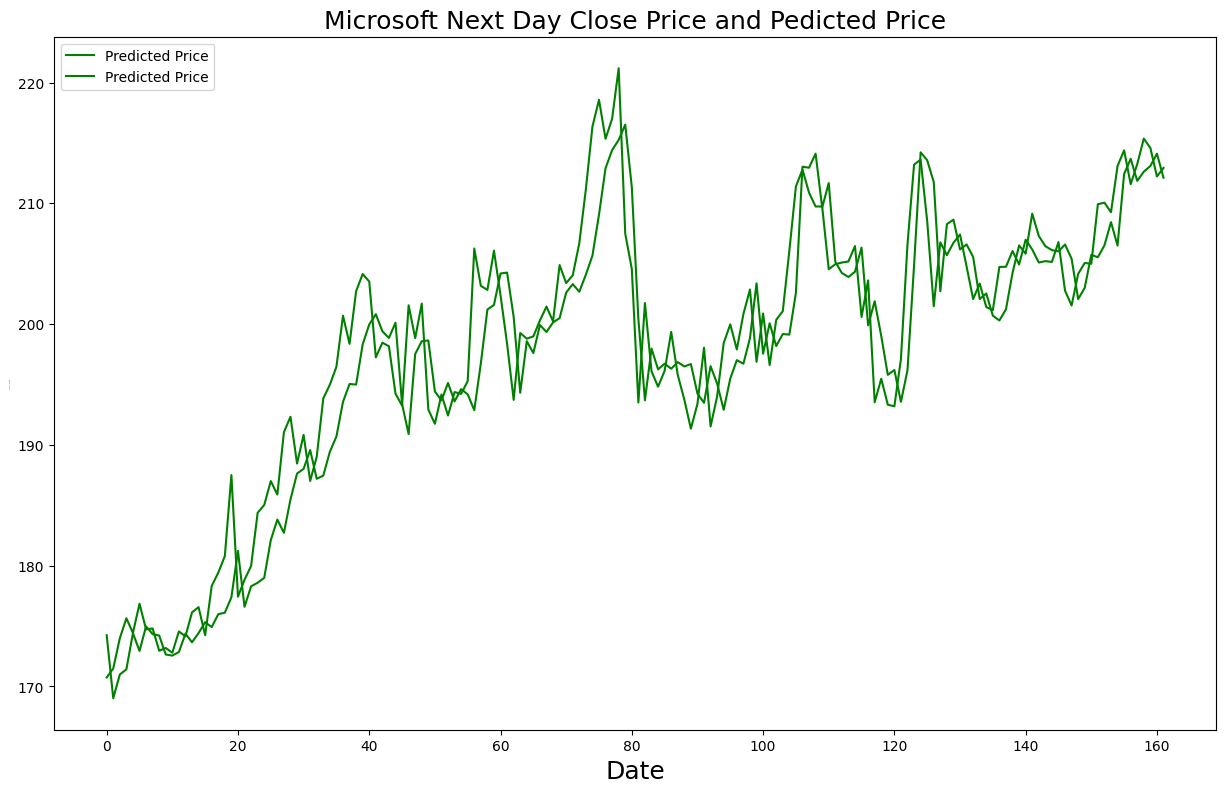

In [39]:
plt.figure(figsize= (15,9))
plt.title('Microsoft Next Day Close Price and Pedicted Price', fontsize  = 18)
plt.plot(df_TP['Target'], label="Predicted Price", color = 'green', alpha=1)
plt.plot(df_TP['Pred'],label="Predicted Price", color = 'green', alpha=1)
plt.xlabel('Date', fontsize = 18)
plt.legend(loc = "upper left")
plt.ylabel('Price in USD $', fontsize = 1)